# Preprocessing
## 1. Preprocess Genomic data

In [123]:
#imports 
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
%matplotlib inline

In [124]:
folder_path = 'Data/sclc_ucologne_2015/unused_data'
file_name = 'data_mrna_seq_fpkm.txt'
file_path = folder_path + '/' + file_name
# Load the RNAseq data from the csv file
data = pd.read_csv(file_path, sep='\t', index_col=0)

In [125]:
# First, we'll filter out genes with zero expression across all patient samples
df_filtered = data.loc[~(data.iloc[:, 2:].eq(0).all(axis=1))]

# Group by 'Hugo_Symbol', take the mean of each group, and reset the index
df_filtered = df_filtered.groupby('Hugo_Symbol').mean().reset_index()

# Calculate the sum of FPKM for each sample (each column starting from the third column)
sum_fpkm_per_sample = df_filtered.iloc[:, 2:].sum()

# Convert FPKM to TPM
# Divide each FPKM value by the sum of FPKM for that sample, then multiply by 10^6
df_tpm = df_filtered.copy()
df_tpm.iloc[:, 2:] = (df_filtered.iloc[:, 2:].div(sum_fpkm_per_sample)) * 10**6


# Drop the 'Entrez_Gene_Id' column
df_tpm = df_tpm.drop('Entrez_Gene_Id', axis=1)
#change name of column Hugo Symbol to gene gene_id
#df_tpm = df_tpm.rename(columns={'Hugo_Symbol': 'gene_id'})
df_tpm = df_tpm.rename(columns={'Hugo_Symbol': 'PATIENT_ID'})
# transpose the dataframe
df_tpm = df_tpm.T

# Make the gene_id row the column names
df_tpm.columns = df_tpm.iloc[0]
#delete the gene_id row
df_tpm = df_tpm.drop('PATIENT_ID')

#save the TPM data to a csv file
df_tpm.to_csv('Data/sclc_ucologne_2015/data_mrna_seq_tpm.csv', index=True)


## Process clinical data for SCLC

In [ ]:
folder_path = 'Data/sclc_ucologne_2015'
file_name = 'data_clinical_patient_original.txt'
file_path = folder_path + '/' + file_name
# Load the clinical data from the csv file
data = pd.read_csv(file_path, sep='\t', index_col=0, header=0,skiprows=4, usecols=['PATIENT_ID','AGE', 'ETHNICITY', 'SEX', 'OS_STATUS', 'OS_MONTHS']  )

# the columns correspond to the patient IDs
# delete rows with no OS_STATUS
data = data[data['OS_STATUS'].notna()]


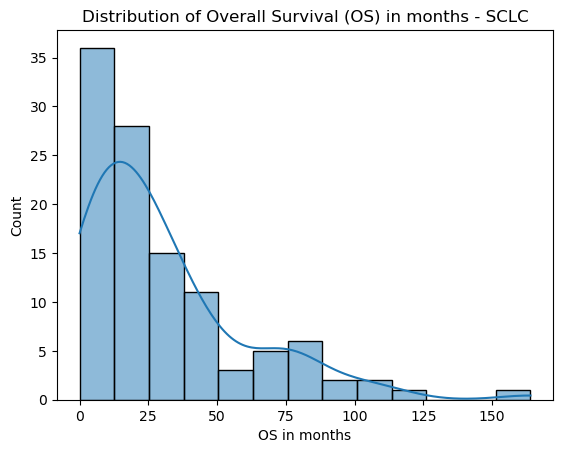

In [ ]:
# plot distribution of OS_MONTHS
import seaborn as sns
import matplotlib.pyplot as plt


sns.histplot(data['OS_MONTHS'], kde=True)
plt.title('Distribution of Overall Survival (OS) in months - SCLC')
plt.xlabel('OS in months')
plt.show()

In [ ]:
#Relebelling to align with the nomenclature used in TCGA

data["race"] = data["ETHNICITY"] # TCGA only has the categories 'Hispanic or Latino', 
#'Not Hispanic or Latino', and 'Not reported', so we'll use race as a starting point
data['age_at_diagnosis'] = data['AGE']
data['year_of_diagnosis'] = 2015 # All patients were diagnosed in 2015
data['year_of_birth'] = 2015 - data['AGE'] 
data['overall_survival'] = data['OS_MONTHS']
data['vital_status'] = data['OS_STATUS']
data['disease_specific_survival'] = data['OS_MONTHS']
data['primary_site'] = 'Bronchus and lung'

#replace "Asian" with "NOT HISPANIC OR LATINO, other with nan
data["ETHNICITY"].replace({"Asian": "NOT HISPANIC OR LATINO"}, inplace=True)
# Replace all other values that are not "NOT HISPANIC OR LATINO" with NaN
data["ETHNICITY"] = data["ETHNICITY"].apply(lambda x: "NOT HISPANIC OR LATINO" if x == "NOT HISPANIC OR LATINO" else np.nan)
data["race"].replace({"Caucasian": "WHITE", "Asian": "ASIAN"}, inplace=True)
#change column names
data.rename(columns = {'PATIENT_ID':'patient_id', 'SEX': 'gender', 'ETHNICITY':'ethnicity' }, inplace = True)
#drop AGE, OS_STATUS, OS_MONTHS
data.drop(columns = ['AGE', 'OS_STATUS', 'OS_MONTHS'], inplace = True)
#replace vital status labels with the nomenclature 1:DECEASED 0:LIVING
data["vital_status"].replace({"1:DECEASED": 1, "0:LIVING": 0}, inplace=True)

#Use the following categories:
#0: Not Known
#1: 'NOT HISPANIC OR LATINO'
data.ethnicity.replace({"NOT HISPANIC OR LATINO": 1}, inplace=True)
data.ethnicity.fillna(0, inplace=True)

data.race.replace({"WHITE": 1, "ASIAN": 2}, inplace=True)
data.race.fillna(0, inplace=True)
#drop rows with null overall_survival
data.dropna(subset=['overall_survival'], inplace=True)


In [ ]:
# Display data to check for any anomalies
data

,gender,ethnicity,race,age_at_diagnosis,year_of_diagnosis,year_of_birth,overall_survival,vital_status,disease_specific_survival,primary_site
PATIENT_ID,,,,,,,,,,
sclc_ucologne_2015_S00022,Male,0.0,0.0,47.0,2015,1968.0,38.0,1,38.0,Bronchus and lung
sclc_ucologne_2015_S00035,Female,0.0,0.0,65.0,2015,1950.0,12.0,1,12.0,Bronchus and lung
sclc_ucologne_2015_S00050,Male,0.0,0.0,47.0,2015,1968.0,42.0,1,42.0,Bronchus and lung
sclc_ucologne_2015_S00213,Male,0.0,0.0,65.0,2015,1950.0,13.0,1,13.0,Bronchus and lung
sclc_ucologne_2015_S00356,Female,0.0,0.0,54.0,2015,1961.0,33.0,1,33.0,Bronchus and lung
...,...,...,...,...,...,...,...,...,...,...
sclc_ucologne_2015_S02400,Male,1.0,2.0,44.0,2015,1971.0,0.0,1,0.0,Bronchus and lung
sclc_ucologne_2015_S02401,Male,1.0,2.0,72.0,2015,1943.0,1.0,0,1.0,Bronchus and lung
sclc_ucologne_2015_S02402,Male,1.0,2.0,57.0,2015,1958.0,47.0,0,47.0,Bronchus and lung


In [ ]:
#save to csv
data.to_csv(folder_path + '/data_clinical_patient.csv', sep=',')

# Model 


In [ ]:
import argparse
from datetime import datetime
from pathlib import Path
from warnings import filterwarnings

import lightning.pytorch as pl
import pandas as pd
import torch
import yaml
from tqdm import tqdm

from dataset import TCGA_Program_Dataset
from datasets_manager import TCGA_Balanced_Datasets_Manager, TCGA_Datasets_Manager
from lit_models import LitFullModel
from model import Classifier, Feature_Extractor, Graph_And_Clinical_Feature_Extractor, Task_Classifier
from utils import config_add_subdict_key, get_logger, override_n_genes, set_random_seed, setup_logging
from external_lightningdatamodule import ExternalDataModule
filterwarnings('ignore', r'.*Skipping val loop.*')
# Suppress specific warning about shuffling in dataloaders
filterwarnings(
    action='ignore',
    message=".*shuffling enabled.*",
    category=UserWarning,  # Adjust the category if necessary
    module='pytorch_lightning'  # Adjust if the warning is from a different module
)  


SEED = 1126
set_random_seed(SEED)


In [ ]:

def create_models_and_optimizers(config: dict):
    models: dict[str, torch.nn.Module] = {}
    optimizers: dict[str, torch.optim.Optimizer] = {}

    # Setup models. Do not use getattr() for better IDE support.
    for model_name, kargs in config['models'].items():
        if model_name == 'Graph_And_Clinical_Feature_Extractor':
            models['feat_ext'] = Graph_And_Clinical_Feature_Extractor(**kargs)
        elif model_name == 'Feature_Extractor':
            models['feat_ext'] = Feature_Extractor(**kargs)
        elif model_name == 'Task_Classifier':
            models['clf'] = Task_Classifier(**kargs)
        elif model_name == 'Classifier':
            models['clf'] = Classifier(**kargs)
        else:
            raise ValueError(f'Unknown model type: {model_name}')

    # Setup optimizers. If the key is 'all', the optimizer will be applied to all models.
    for key, optim_dict in config['optimizers'].items():
        opt_name = next(iter(optim_dict))
        if key == 'all':
            params = [param for model in models.values() for param in model.parameters()]
            optimizers[key] = getattr(torch.optim, opt_name)(params, **optim_dict[opt_name])
        else:
            optimizers[key] = getattr(torch.optim, opt_name)(models[key].parameters(), **optim_dict[opt_name])

    # Add models' structure to config for logging. TODO: Prettify.
    for model_name, torch_model in models.items():
        config[f'model.{model_name}'] = str(torch_model)
    return models, optimizers



In [ ]:
def cross_validation(manager, config, log_path, external_testing_dataloader):
    for key, values in manager['TCGA_BLC']['dataloaders'].items():
        if isinstance(key, int) and config['cross_validation']:
            models, optimizers = create_models_and_optimizers(config)
            lit_model = LitFullModel(models, optimizers, config)
            trainer = pl.Trainer(                                               # Create sub-folders for each fold.
                default_root_dir=log_path,
                max_epochs=config['max_epochs'],
                log_every_n_steps=1,
                enable_model_summary=False,
                enable_checkpointing=False,
                
            )
            
            trainer.fit(lit_model, train_dataloaders=values['train'])
            
        
        elif key == 'train':
            train = values
        elif key == 'test':
            test = external_testing_dataloader #values
    return train, test

In [ ]:


def main(config_file):
    # Select a config file.

    # parser = argparse.ArgumentParser()
    # parser.add_argument('-c', '--config', type=str, help='Path to the config file.', required=True)
    # args = parser.parse_args()
    with open(config_file, 'r') as f:
        config = yaml.load(f, Loader=yaml.FullLoader)
    override_n_genes(config)                        # For multi-task graph models.
    config_name = Path(config_file).stem

    # Setup logging.
    log_path = f'Logs/{config_name}/{datetime.now():%Y-%m-%dT%H:%M:%S}/'
    setup_logging(log_path)
    
    logger = get_logger(config_name)
    logger.info(f'Using Random Seed {SEED} for this experiment')
    get_logger('lightning.pytorch.accelerators.cuda', log_level='WARNING')      # Disable cuda logging.
    filterwarnings('ignore', r'.*Skipping val loop.*')                          # Disable val loop warning.
    filterwarnings('ignore', r".*Your `test_dataloader`'s sampler has `shuffle=True`.*")    # Disable val shuffle warning.

     # Create dataset manager for training data.
    data = {'TCGA_BLC': TCGA_Program_Dataset(**config['datasets'])}
    
    #add the external data
    external_testing_data = ExternalDataModule(**config['external_datasets']) 

    external_testing_data.setup()

    external_testing_dataloader = external_testing_data.test_dataloader()
    
    if 'TCGA_Balanced_Datasets_Manager' == config['datasets_manager']['type']:
        manager = TCGA_Balanced_Datasets_Manager(datasets=data, config=config_add_subdict_key(config))
    else:
        manager = TCGA_Datasets_Manager(datasets=data, config=config_add_subdict_key(config))

    
    for key, values in manager['TCGA_BLC']['dataloaders'].items():
        if isinstance(key, int) and config['cross_validation']:
            models, optimizers = create_models_and_optimizers(config)
            lit_model = LitFullModel(models, optimizers, config)
            trainer = pl.Trainer(                                               # Create sub-folders for each fold.
                default_root_dir=log_path,
                max_epochs=config['max_epochs'],
                log_every_n_steps=1,
                enable_model_summary=False,
                enable_checkpointing=False,
                
            )
            
            trainer.fit(lit_model, train_dataloaders=values['train'])
            #trainer.test(lit_model, dataloaders=test, verbose=True)          
               
            
        elif key == 'train':
            train = values
        elif key == 'test':
            test = external_testing_dataloader #values

    # Train the final model from scratch with all the training data.
    models, optimizers = create_models_and_optimizers(config)
    lit_model = LitFullModel(models, optimizers, config)
    trainer = pl.Trainer(
        default_root_dir=log_path,
        max_epochs=config['max_epochs'],
        enable_progress_bar=False,
        log_every_n_steps=1,
        logger=False,
    )
    trainer.fit(lit_model, train_dataloaders=train)

    # Test the final model.
    bootstrap_results = []
    for _ in tqdm(range(config['bootstrap_repeats']), desc='Bootstrapping'):       
        bootstrap_results.append(trainer.test(lit_model, dataloaders=test, verbose=False)[0]) 
    bootstrap_results = pd.DataFrame.from_records(bootstrap_results)
    for key, value in bootstrap_results.describe().loc[['mean', 'std']].to_dict().items():
        logger.info(f'| {key.ljust(10).upper()} | {value["mean"]:.5f} ± {value["std"]:.5f} |')
        
    return trainer, train, test, models, optimizers, config



# Model evaluation
The results correspond to the "MTL - SCLC" row of Table 3.

In [ ]:

 # Run the main function.
trainer, train, test, models, optimizers, config = main("config/light/MTL_train_SCLC_test.yaml")



[INFO]	Using Random Seed 1126 for this experiment
[INFO]	Creating a TCGA Program Dataset with 3 Projects...


[INFO]	All files are downloaded for TCGA-BRCA
[INFO]	Creating 1093 cases for TCGA-BRCA...
[INFO]	Using genomic tpm cache files created at 2024-02-23 10:53:54 for TCGA-BRCA
[INFO]	Using clinical cache files created at 2024-02-23 10:54:21 for TCGA-BRCA
[INFO]	Using vital status cache files created at 2024-02-23 10:54:29 for TCGA-BRCA
[INFO]	Using overall survival cache files created at 2024-02-23 10:54:37 for TCGA-BRCA
[INFO]	Using disease specific survival cache files created at 2024-02-23 10:54:46 for TCGA-BRCA
[INFO]	Using survival time cache files created at 2024-02-23 10:54:53 for TCGA-BRCA
[INFO]	Using primary site cache files created at 2024-02-23 10:55:06 for TCGA-BRCA
[INFO]	All files are downloaded for TCGA-LUAD
[INFO]	Creating 510 cases for TCGA-LUAD...
[INFO]	Using genomic tpm cache files created at 2024-02-23 11:41:50 for TCGA-LUAD
[INFO]	Using clinical cache files created at 2024-02-23 11:41:58 for TCGA-LUAD
[INFO]	Using vital status cache files created at 2024-02-23 11:41:

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Missing logger folder: Logs/MTL_train_SCLC_test/2024-04-30T21:19:01/lightning_logs


Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 28.82it/s, v_num=0]

`Trainer.fit` stopped: `max_epochs=50` reached.


...

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 10/10 [00:00<00:00, 28.05it/s, v_num=3]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs



  | Name       | Type              | Params
-------------------------------------------------
0 | feat_ext   | Feature_Extractor | 503   
1 | classifier | Task_Classifier   | 273   
-------------------------------------------------
776       Trainable params
0         Non-trainable params
776       Total params
0.003     Total estimated model params size (MB)
`Trainer.fit` stopped: `max_epochs=50` reached.
Bootstrapping: 100%|██████████| 1000/1000 [06:10<00:00,  2.70it/s]

[INFO]	| YOUDEN_2.0 | 0.26192 ± 0.03321 |
[INFO]	| AUC_2.0    | 0.67597 ± 0.10212 |
[INFO]	| PRC_2.0    | 0.29910 ± 0.11533 |
[INFO]	| C-INDEX_2.0 | 0.46350 ± 0.04072 |


In [ ]:

# Load last trained model and check for the outputs

latest_datetime = max(os.listdir('Logs/MTL_train_SCLC_test/'))
weights_path = f'Logs/MTL_train_SCLC_test/{latest_datetime}/checkpoints/epoch=49-step=1300.ckpt'
lit_model = LitFullModel.load_from_checkpoint(weights_path,  models=models, optimizers=optimizers, config=config)
# show the model output
 
trainer.test(lit_model, dataloaders=test, verbose=True)



TypeError: __init__() got an unexpected keyword argument 'mode'